## Импорт библиотек и настройки

In [1]:
from pathlib import Path
import time
import warnings
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate
from sklearn.tree import DecisionTreeClassifier, plot_tree

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
RANDOM_STATE = 42
DATA_DIR = Path('../data/processed')
FIGURES_DIR = Path('../reports/figures')
MODELS_DIR = Path('../models')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

## Загрузка подготовленных выборок

In [2]:
required_files = [
    'X_train.npy', 'X_val.npy', 'X_test.npy',
    'y_train.npy', 'y_val.npy', 'y_test.npy',
    'feature_names.txt'
]
missing_files = [name for name in required_files if not (DATA_DIR / name).exists()]
if missing_files:
    raise FileNotFoundError(
        'Не найдены подготовленные файлы: '
        + ', '.join(missing_files)
        + '. Сначала выполните 01_EDA.ipynb.'
    )
X_train = np.load(DATA_DIR / 'X_train.npy')
X_val = np.load(DATA_DIR / 'X_val.npy')
X_test = np.load(DATA_DIR / 'X_test.npy')
y_train = np.load(DATA_DIR / 'y_train.npy')
y_val = np.load(DATA_DIR / 'y_val.npy')
y_test = np.load(DATA_DIR / 'y_test.npy')
feature_names = (DATA_DIR / 'feature_names.txt').read_text(
    encoding='utf-8'
).splitlines()
print('Train:', X_train.shape, y_train.shape)
print('Validation:', X_val.shape, y_val.shape)
print('Test:', X_test.shape, y_test.shape)
print('Количество признаков:', len(feature_names))

Train: (180, 13) (180,)
Validation: (61, 13) (61,)
Test: (61, 13) (61,)
Количество признаков: 13


Проверка данных на размер

In [3]:
assert X_train.shape[0] == y_train.shape[0]
assert X_val.shape[0] == y_val.shape[0]
assert X_test.shape[0] == y_test.shape[0]
assert X_train.shape[1] == X_val.shape[1] == X_test.shape[1]
assert X_train.shape[1] == len(feature_names)
assert set(np.unique(y_train)) == {0, 1}

## Функция расчёта метрик

In [ ]:
def calculate_metrics(model, X, y, sample_name):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    return {
        'Выборка': sample_name,
        'Accuracy': accuracy_score(y, y_pred),
        'Precision': precision_score(y, y_pred, zero_division=0),
        'Recall': recall_score(y, y_pred, zero_division=0),
        'F1': f1_score(y, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y, y_proba),
    }

def compare_on_train_and_val(model):
    return pd.DataFrame([
        calculate_metrics(model, X_train, y_train, 'Train'),
        calculate_metrics(model, X_val, y_val, 'Validation'),
    ]).set_index('Выборка')

## Базовое решающее дерево без ограничения глубины

In [5]:
baseline_tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
baseline_tree.fit(X_train, y_train)
baseline_metrics = compare_on_train_and_val(baseline_tree)
display(baseline_metrics.style.format('{:.3f}'))
print('Глубина дерева:', baseline_tree.get_depth())
print('Количество листьев:', baseline_tree.get_n_leaves())

,Accuracy,Precision,Recall,F1,ROC-AUC
Выборка,,,,,
Train,1.000,1.000,1.000,1.000,1.000
Validation,0.689,0.719,0.697,0.708,0.688


Глубина дерева: 7
Количество листьев: 28


Заметим, что дерево без ограничения на глубину идеально запоминает обучающую выборку. Высокое качество на train вместе с заметно меньшим качеством на validation является признаком переобучения

## Визуализация базового дерева

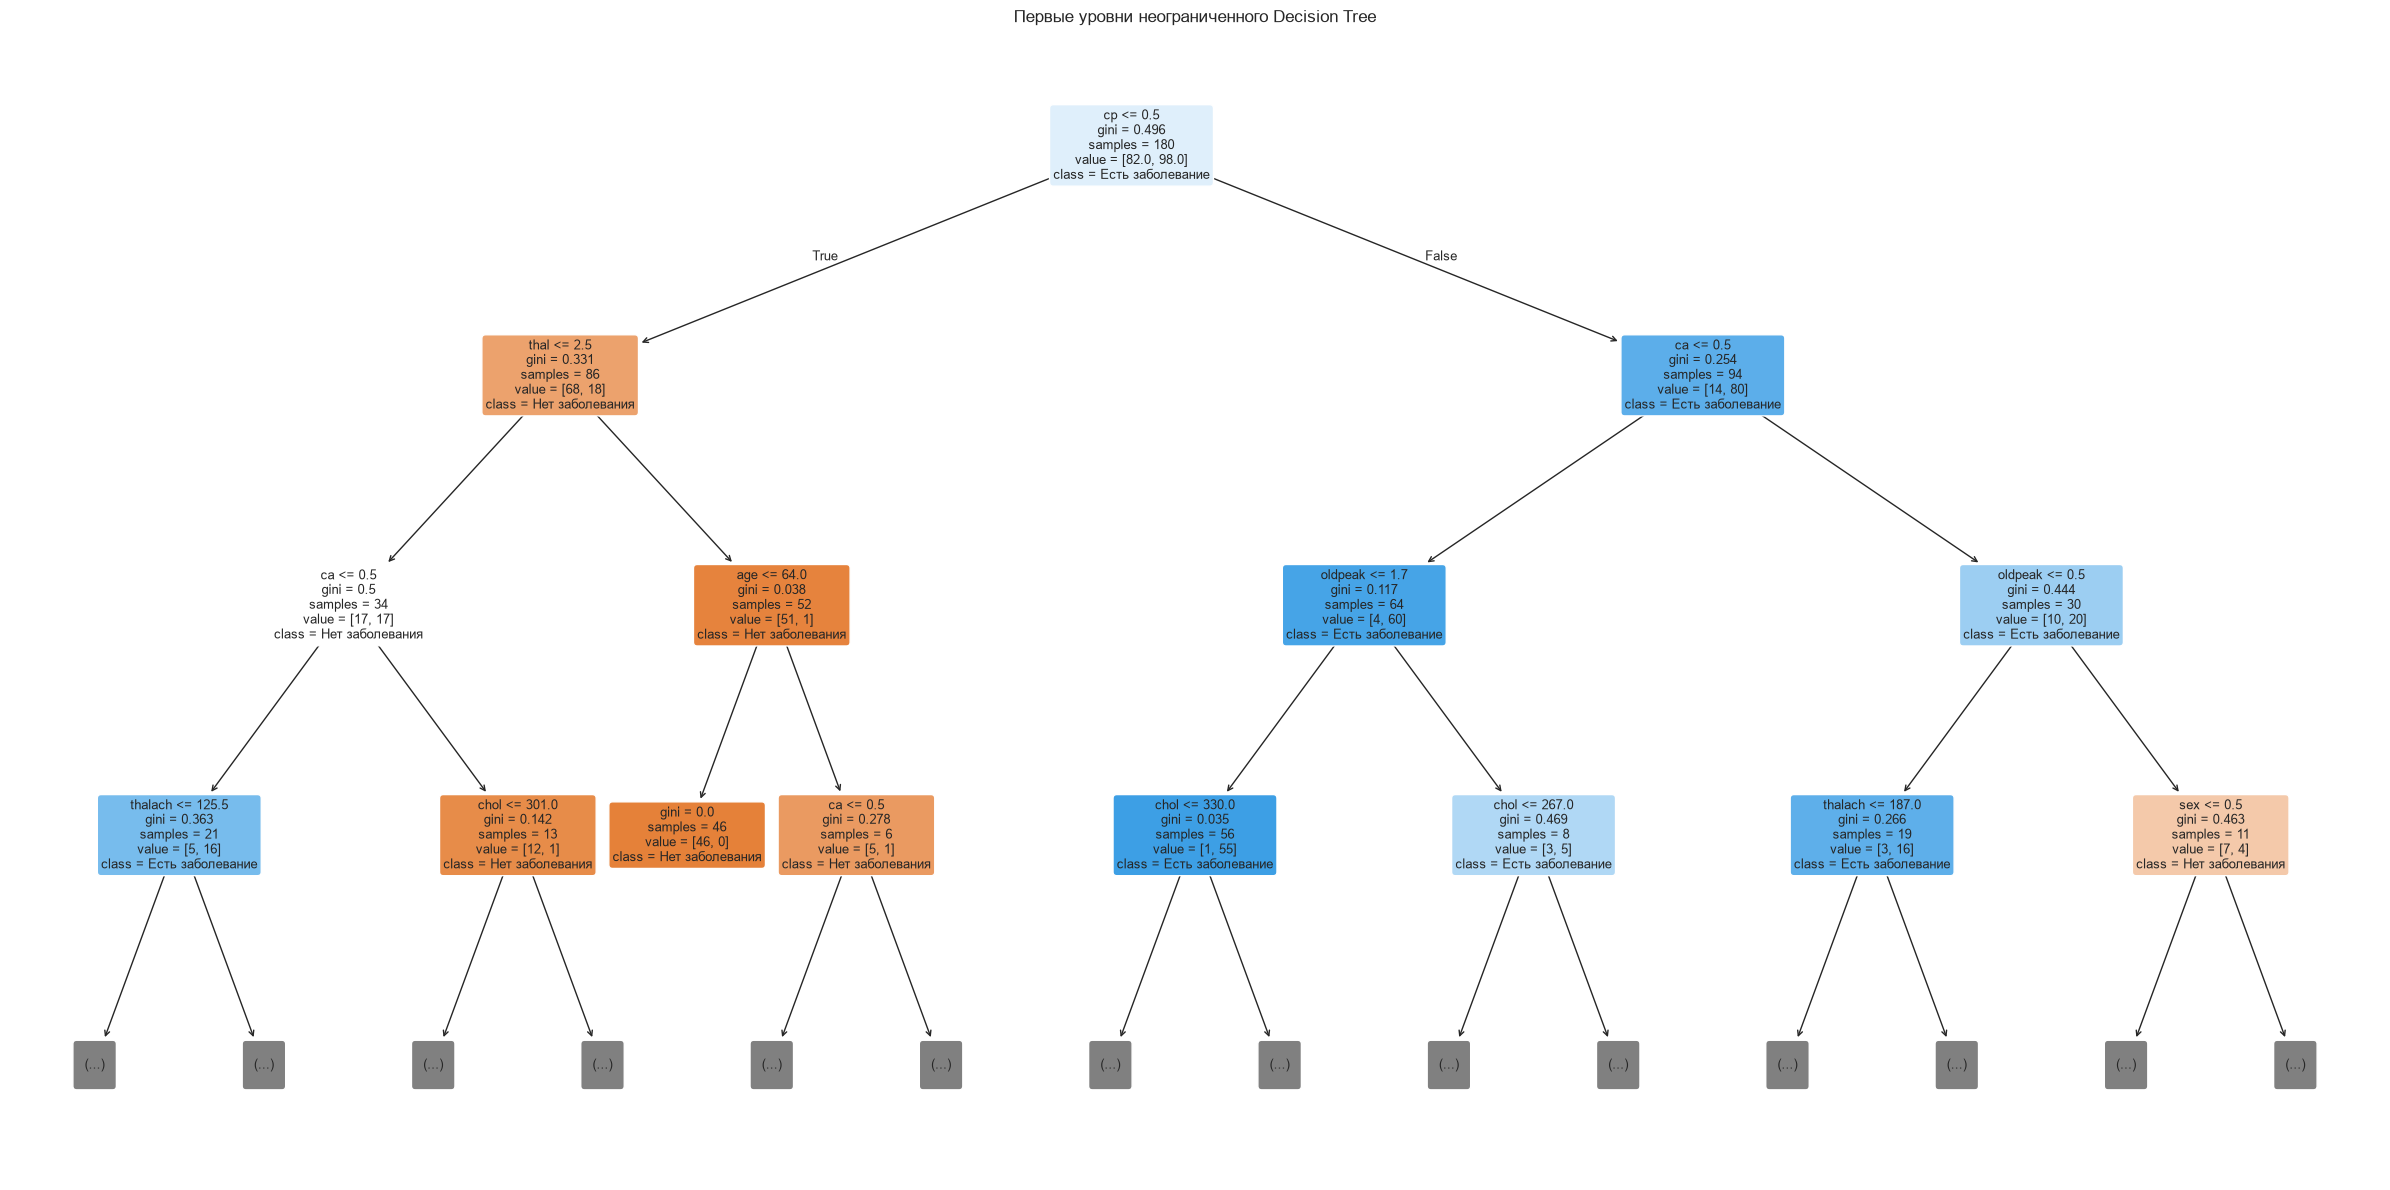

In [6]:
plt.figure(figsize=(24, 12))
plot_tree(
    baseline_tree,
    feature_names=feature_names,
    class_names=['Нет заболевания', 'Есть заболевание'],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9,
)
plt.title('Первые уровни неограниченного Decision Tree')
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / 'baseline_tree_first_levels.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

В каждой вершине дерево жадно выбирает признак и порог, которые дают наибольшее уменьшение неопределённости

Критерий Gini для распределения классов $p_k$ имеет вид:

$$Gini = 1 - \sum_k p_k^2$$

Энтропия определяется как:

$$Entropy = -\sum_k p_k \log_2 p_k$$

Оба критерия равны нулю в полностью однородной вершине

## Сравнение критериев Gini и Entropy

In [7]:
criterion_results = []
for criterion in ['gini', 'entropy']:
    model = DecisionTreeClassifier(
        criterion=criterion,
        random_state=RANDOM_STATE
    )
    start = time.perf_counter()
    model.fit(X_train, y_train)
    fit_time = time.perf_counter() - start
    val_metrics = calculate_metrics(model, X_val, y_val, 'Validation')
    criterion_results.append({
        'Критерий': criterion,
        'Глубина': model.get_depth(),
        'Листья': model.get_n_leaves(),
        'Время обучения, сек': fit_time,
        **{key: value for key, value in val_metrics.items() if key != 'Выборка'}
    })
criterion_results_df = pd.DataFrame(criterion_results).set_index('Критерий')
display(criterion_results_df.style.format('{:.3f}'))

,Глубина,Листья,"Время обучения, сек",Accuracy,Precision,Recall,F1,ROC-AUC
Критерий,,,,,,,,
gini,7.000,28.000,0.003,0.689,0.719,0.697,0.708,0.688
entropy,7.000,25.000,0.002,0.656,0.688,0.667,0.677,0.655


Заметим, что $Gini$ доминирует во всех метриках, чем $Entropy$, хоть и с небольшой разницей

## Зависимость качества от глубины дерева

In [8]:
depth_values = range(1, 21)
depth_results = []
for depth in depth_values:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=RANDOM_STATE
    )
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    train_proba = model.predict_proba(X_train)[:, 1]
    val_proba = model.predict_proba(X_val)[:, 1]
    depth_results.append({
        'max_depth': depth,
        'Train Accuracy': accuracy_score(y_train, train_pred),
        'Validation Accuracy': accuracy_score(y_val, val_pred),
        'Train F1': f1_score(y_train, train_pred),
        'Validation F1': f1_score(y_val, val_pred),
        'Train ROC-AUC': roc_auc_score(y_train, train_proba),
        'Validation ROC-AUC': roc_auc_score(y_val, val_proba),
    })
depth_results_df = pd.DataFrame(depth_results)
display(depth_results_df.round(3))

,max_depth,Train Accuracy,Validation Accuracy,Train F1,Validation F1,Train ROC-AUC,Validation ROC-AUC
0,1,0.822,0.672,0.833,0.706,0.823,0.667
1,2,0.822,0.672,0.833,0.706,0.908,0.735
2,3,0.900,0.705,0.911,0.735,0.958,0.742
3,4,0.944,0.705,0.949,0.735,0.983,0.718
4,5,0.978,0.705,0.980,0.735,0.997,0.719
5,6,0.983,0.689,0.984,0.716,0.999,0.684
6,7,1.000,0.689,1.000,0.708,1.000,0.688
7,8,1.000,0.689,1.000,0.708,1.000,0.688
8,9,1.000,0.689,1.000,0.708,1.000,0.688
9,10,1.000,0.689,1.000,0.708,1.000,0.688


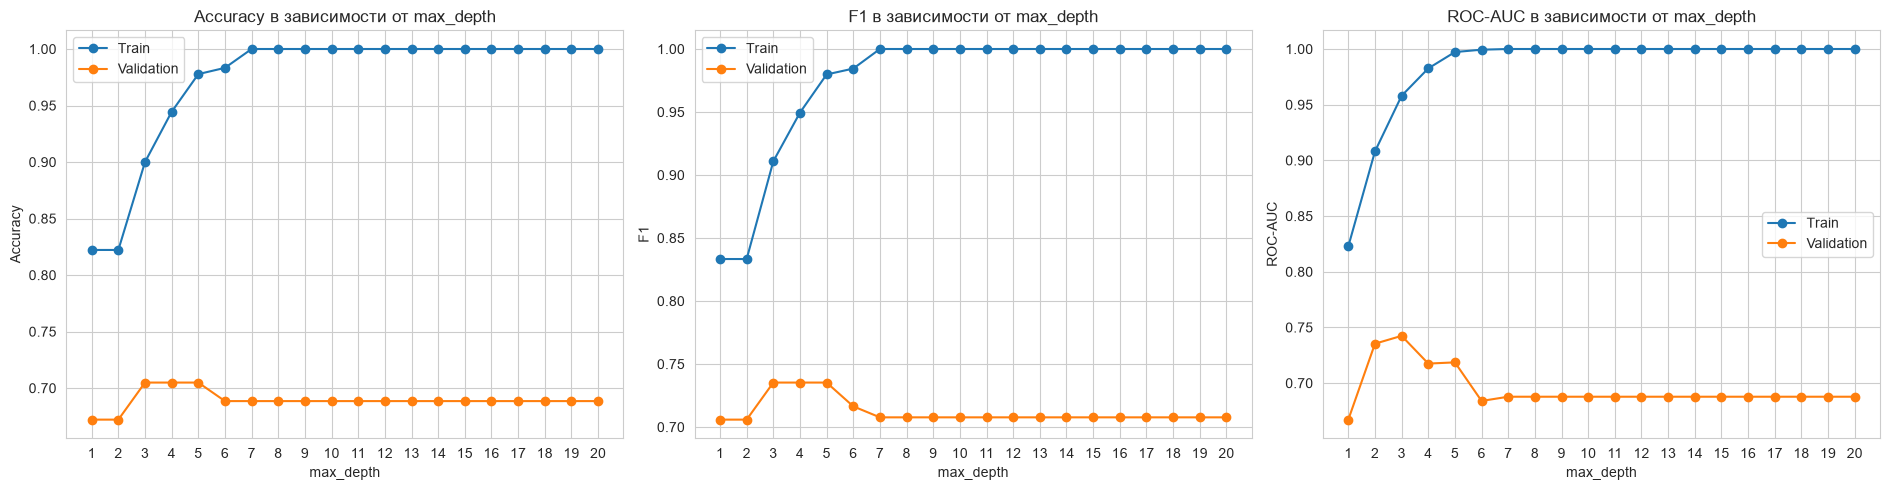

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
metrics_to_plot = ['Accuracy', 'F1', 'ROC-AUC']
for ax, metric in zip(axes, metrics_to_plot):
    ax.plot(
        depth_results_df['max_depth'],
        depth_results_df[f'Train {metric}'],
        marker='o',
        label='Train'
    )
    ax.plot(
        depth_results_df['max_depth'],
        depth_results_df[f'Validation {metric}'],
        marker='o',
        label='Validation'
    )
    ax.set_title(f'{metric} в зависимости от max_depth')
    ax.set_xlabel('max_depth')
    ax.set_ylabel(metric)
    ax.set_xticks(list(depth_values))
    ax.legend()
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / 'decision_tree_depth_overfitting.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

In [10]:
best_depth_by_val_auc = int(
    depth_results_df.loc[
        depth_results_df['Validation ROC-AUC'].idxmax(),
        'max_depth'
    ]
)
print('Лучшая глубина по Validation ROC-AUC:', best_depth_by_val_auc)
display(
    depth_results_df.loc[
        depth_results_df['Validation ROC-AUC'].idxmax()
    ].to_frame('Значение').round(3)
)

Лучшая глубина по Validation ROC-AUC: 3


,Значение
max_depth,3.000
Train Accuracy,0.900
Validation Accuracy,0.705
Train F1,0.911
Validation F1,0.735
Train ROC-AUC,0.958
Validation ROC-AUC,0.742


### Смещение и разброс

Неглубокое дерево имеет простую структуру: оно устойчиво к небольшим изменениям данных, но может не уловить реальные зависимости. Это высокое смещение и низкий разброс

Глубокое дерево способно почти идеально описать train и поэтому имеет низкое смещение, однако отдельные объекты сильно влияют на структуру глубокого дерева, поэтому при изменении обучающей выборки дерево может заметно измениться. Это высокий разброс

## Оценка стабильности с помощью StratifiedKFold

In [11]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)
cv_scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
}
cv_results = cross_validate(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    X_train,
    y_train,
    cv=cv,
    scoring=cv_scoring,
    return_train_score=True,
)
cv_summary = []
for metric in cv_scoring:
    cv_summary.append({
        'Метрика': metric,
        'Train mean': cv_results[f'train_{metric}'].mean(),
        'CV mean': cv_results[f'test_{metric}'].mean(),
        'CV std': cv_results[f'test_{metric}'].std(),
    })
cv_summary_df = pd.DataFrame(cv_summary).set_index('Метрика')
display(cv_summary_df.style.format('{:.3f}'))

,Train mean,CV mean,CV std
Метрика,,,
accuracy,1.000,0.789,0.033
precision,1.000,0.812,0.048
recall,1.000,0.807,0.086
f1,1.000,0.805,0.033
roc_auc,1.000,0.788,0.035


`CV std` показывает, насколько результат меняется между фолдами. Большое стандартное отклонение указывает на нестабильность модели и высокий разброс.

## Подбор гиперпараметров

In [12]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, 5, 6, 8, 10, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2'],
    'class_weight': [None, 'balanced'],
}
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=True,
)
grid_search.fit(X_train, y_train)
print('Лучший средний CV ROC-AUC:', round(grid_search.best_score_, 3))
print('Лучшие параметры:')
for parameter, value in grid_search.best_params_.items():
    print(f'  {parameter}: {value}')

Лучший средний CV ROC-AUC: 0.9
Лучшие параметры:
  class_weight: None
  criterion: gini
  max_depth: 4
  max_features: None
  min_samples_leaf: 8
  min_samples_split: 2


In [13]:
cv_results_df = pd.DataFrame(grid_search.cv_results_)

top_columns = [
    'rank_test_score',
    'mean_train_score',
    'mean_test_score',
    'std_test_score',
    'param_criterion',
    'param_max_depth',
    'param_min_samples_split',
    'param_min_samples_leaf',
    'param_max_features',
    'param_class_weight',
]

top_models = (
    cv_results_df[top_columns]
    .sort_values('rank_test_score')
    .head(10)
)
display(top_models.round(3))

,rank_test_score,mean_train_score,mean_test_score,std_test_score,param_criterion,param_max_depth,param_min_samples_split,param_min_samples_leaf,param_max_features,param_class_weight
350,1,0.966,0.9,0.046,gini,None,10,8,NaN,NaN
351,1,0.966,0.9,0.046,gini,None,15,8,NaN,NaN
349,1,0.966,0.9,0.046,gini,None,5,8,NaN,NaN
348,1,0.966,0.9,0.046,gini,None,2,8,NaN,NaN
303,1,0.966,0.9,0.046,gini,10,15,8,NaN,NaN
302,1,0.966,0.9,0.046,gini,10,10,8,NaN,NaN
111,1,0.966,0.9,0.046,gini,4,15,8,NaN,NaN
110,1,0.966,0.9,0.046,gini,4,10,8,NaN,NaN
109,1,0.966,0.9,0.046,gini,4,5,8,NaN,NaN
108,1,0.966,0.9,0.046,gini,4,2,8,NaN,NaN


## Проверка лучшей конфигурации на validation

In [14]:
best_cv_tree = grid_search.best_estimator_

comparison_table = pd.concat(
    {
        'Неограниченное дерево': compare_on_train_and_val(baseline_tree),
        'Дерево после GridSearchCV': compare_on_train_and_val(best_cv_tree),
    },
    names=['Модель', 'Выборка']
)

display(comparison_table.style.format('{:.3f}'))
print('Глубина лучшего дерева:', best_cv_tree.get_depth())
print('Количество листьев:', best_cv_tree.get_n_leaves())

Глубина лучшего дерева: 4
Количество листьев: 11


## Финальное обучение и однократная оценка на test

После выбора гиперпараметров объединяем train и validation. Лучшая конфигурация заново обучается на всех доступных данных разработки, после чего тестовая выборка используется ровно один раз

In [15]:
X_train_full = np.vstack([X_train, X_val])
y_train_full = np.concatenate([y_train, y_val])
final_tree = DecisionTreeClassifier(
    **grid_search.best_params_,
    random_state=RANDOM_STATE
)
final_tree.fit(X_train_full, y_train_full)
final_metrics = pd.DataFrame([
    calculate_metrics(final_tree, X_train_full, y_train_full, 'Train + Validation'),
    calculate_metrics(final_tree, X_test, y_test, 'Test'),
]).set_index('Выборка')
display(final_metrics.style.format('{:.3f}'))

,Accuracy,Precision,Recall,F1,ROC-AUC
Выборка,,,,,
Train + Validation,0.867,0.878,0.878,0.878,0.956
Test,0.787,0.812,0.788,0.800,0.854


In [16]:
y_test_pred = final_tree.predict(X_test)
print('Classification report для test:')
print(classification_report(
    y_test,
    y_test_pred,
    target_names=['Нет заболевания', 'Есть заболевание'],
    digits=3
))
cm = confusion_matrix(y_test, y_test_pred)
display(pd.DataFrame(
    cm,
    index=['Факт 0', 'Факт 1'],
    columns=['Прогноз 0', 'Прогноз 1']
))

Classification report для test:
                  precision    recall  f1-score   support

 Нет заболевания      0.759     0.786     0.772        28
Есть заболевание      0.812     0.788     0.800        33

        accuracy                          0.787        61
       macro avg      0.786     0.787     0.786        61
    weighted avg      0.788     0.787     0.787        61



,Прогноз 0,Прогноз 1
Факт 0,22,6
Факт 1,7,26


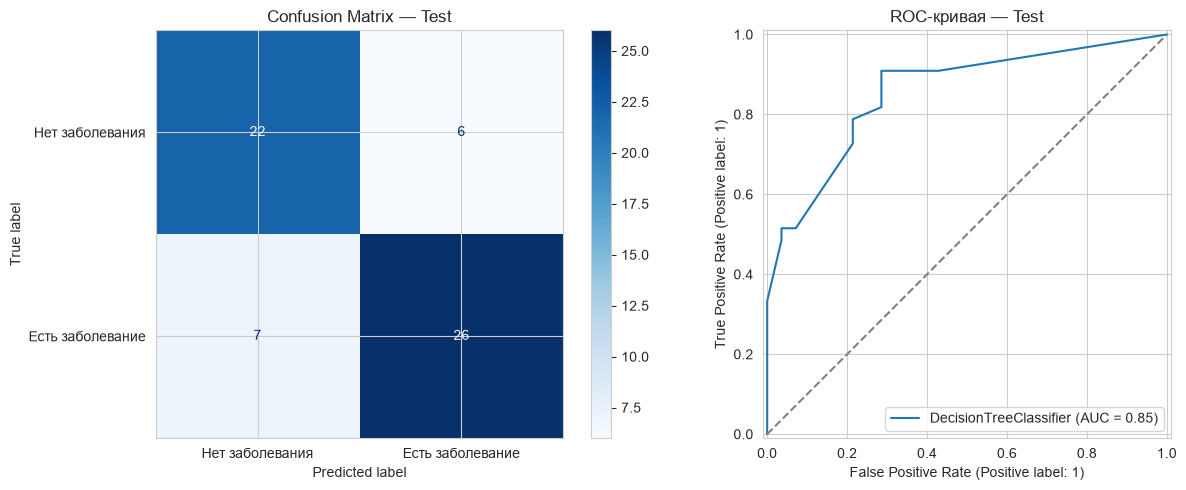

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay.from_estimator(
    final_tree,
    X_test,
    y_test,
    display_labels=['Нет заболевания', 'Есть заболевание'],
    cmap='Blues',
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix — Test')
RocCurveDisplay.from_estimator(final_tree, X_test, y_test, ax=axes[1])
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_title('ROC-кривая — Test')
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / 'baseline_tree_test_metrics.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

## Важность признаков

,Признак,Важность
2,cp,0.481057
11,ca,0.153854
12,thal,0.140042
8,exang,0.057868
10,slope,0.038677
1,sex,0.035341
4,chol,0.026603
9,oldpeak,0.024207
6,restecg,0.023989
7,thalach,0.018362


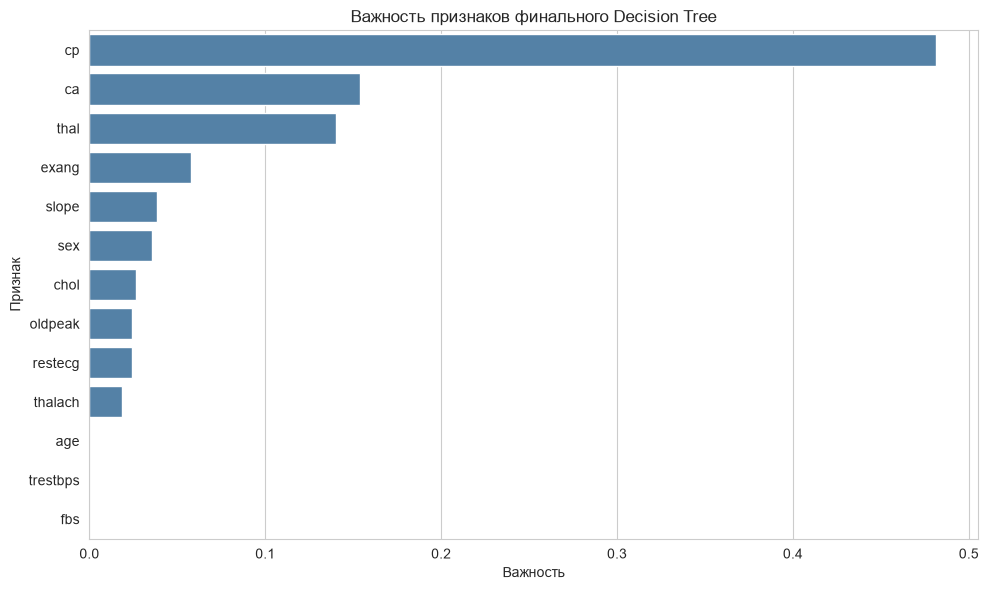

In [18]:
feature_importance = (
    pd.DataFrame({
        'Признак': feature_names,
        'Важность': final_tree.feature_importances_,
    })
    .sort_values('Важность', ascending=False)
)
display(feature_importance)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance,
    x='Важность',
    y='Признак',
    color='steelblue'
)
plt.title('Важность признаков финального Decision Tree')
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / 'baseline_tree_feature_importance.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

## Визуализация финального дерева

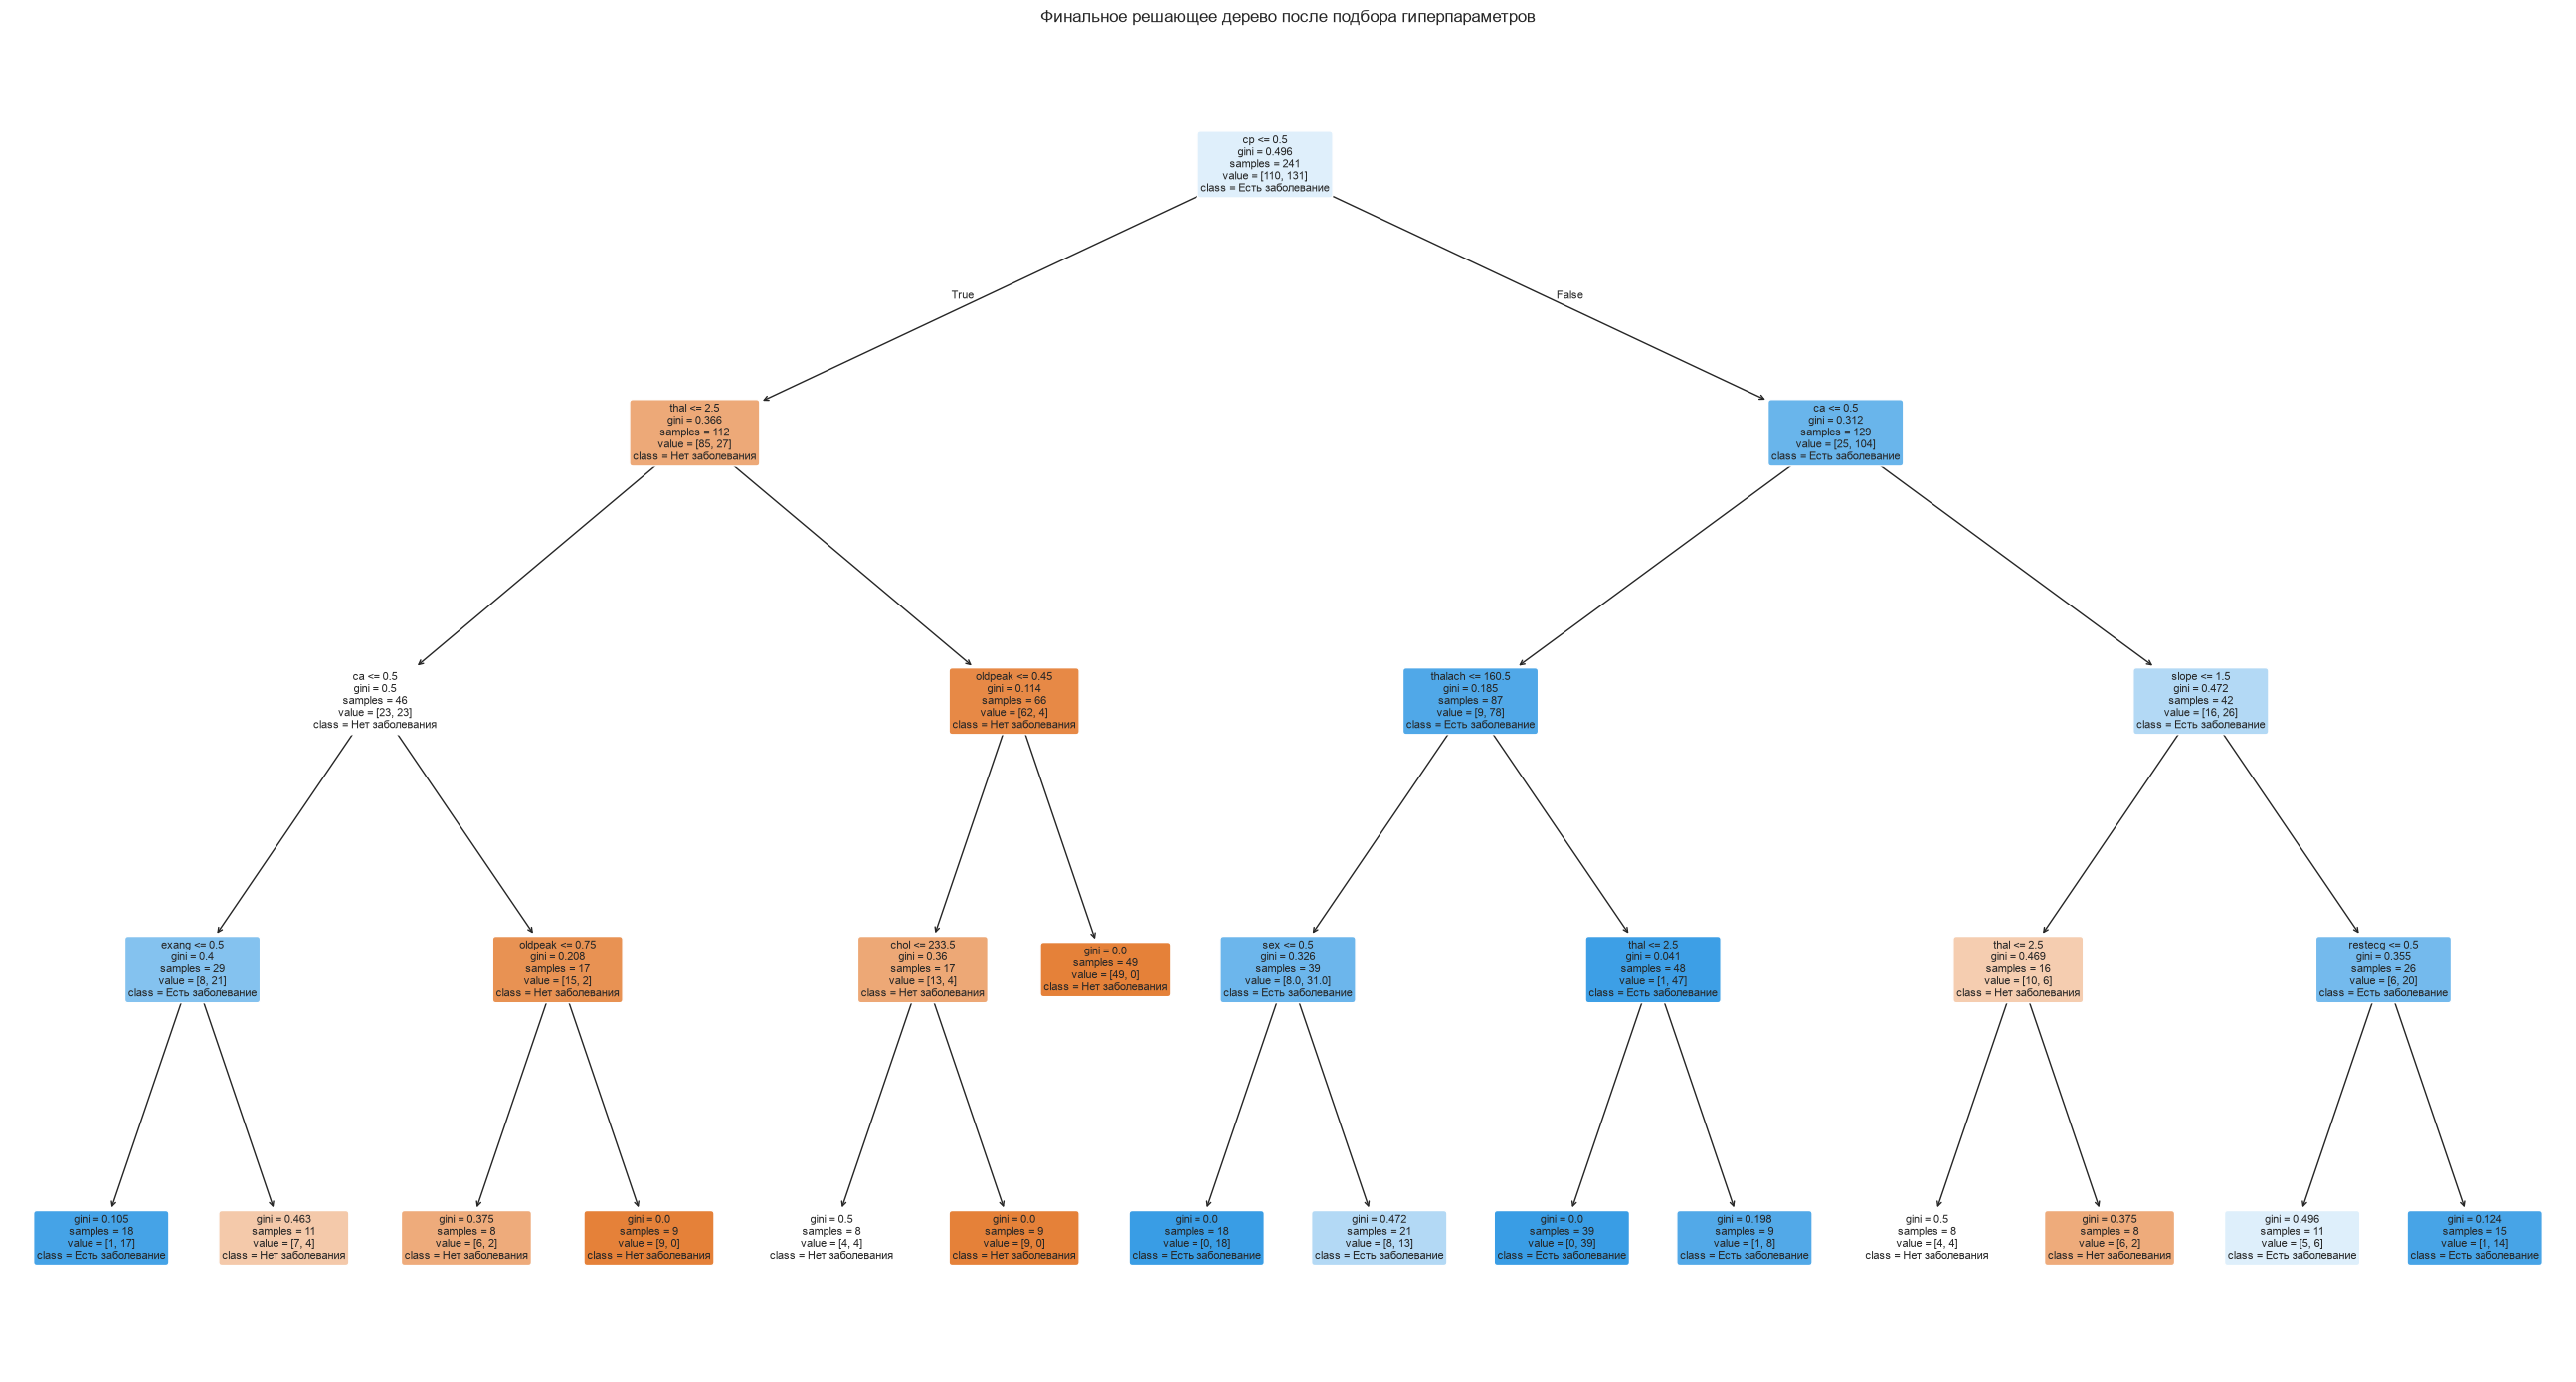

In [19]:
plt.figure(figsize=(26, 14))
plot_tree(
    final_tree,
    feature_names=feature_names,
    class_names=['Нет заболевания', 'Есть заболевание'],
    filled=True,
    rounded=True,
    fontsize=8,
)
plt.title('Финальное решающее дерево после подбора гиперпараметров')
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / 'baseline_tree_optimized.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

## Сохранение модели и результатов

In [20]:
joblib.dump(final_tree, MODELS_DIR / 'base_model.pkl')
final_metrics.to_csv(MODELS_DIR / 'base_model_metrics.csv')
feature_importance.to_csv(
    MODELS_DIR / 'base_model_feature_importance.csv',
    index=False
)
print('Модель сохранена:', (MODELS_DIR / 'base_model.pkl').resolve())
print('Метрики сохранены:', (MODELS_DIR / 'base_model_metrics.csv').resolve())

Модель сохранена: C:\Practice_DecisionTreeClassifier\models\base_model.pkl
Метрики сохранены: C:\Practice_DecisionTreeClassifier\models\base_model_metrics.csv
